In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel(r'E:\Projects\DataAnalysis\Forage\Quantium\data\raw\QVI_transaction_data.xlsx')

In [2]:
org_shape = df.shape
org_dts = df.dtypes
org_desc = df.describe(include = 'all')
org_nulls = df.isna().sum()

In [3]:
org_dts
org_nulls
org_desc

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836,264836.000000,264836.000000
unique,NaN,NaN,NaN,NaN,NaN,114,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,Kettle Mozzarella Basil & Pesto 175g,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,3304,NaN,NaN
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,NaN,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,NaN,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,NaN,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,NaN,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,NaN,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,NaN,2.000000,9.200000


In [4]:
df['TXN_ID'].nunique()
df['LYLTY_CARD_NBR'].nunique()
df['PROD_NBR'].nunique()

114

- Data Type changes required:
    - DATE: int(Excel Series) to Date
- 264836 records, 0 Nulls
- 263127 unique transaction IDs (possible duplicates)
- 72637 unique loyalty card numbers (customers)
- 114 unique Product numbers (114 products)
- max PROD_QTY at 200 with std of 0.64 (Examine for anomolies)
- max TOT_SALES at 650 (Examine for anomolies)

In [5]:
df['DATE'] = pd.to_datetime(df['DATE'], unit='D', origin='1899-12-30')
# Excel series date converted to pd Date

assert ((df['DATE'] >= pd.Timestamp('2018-07-01')) & (df['DATE'] <= pd.Timestamp('2019-06-30'))).all()

Duplicates

In [6]:
df[df.duplicated()]
df[df['TXN_ID'] == 108462]
# One duplicated transaction with full row duplication, Drop
df.drop_duplicates(inplace=True)

In [7]:
df[df.duplicated(subset=['TXN_ID','LYLTY_CARD_NBR','STORE_NBR'])]
df[df.duplicated(subset=['TXN_ID','LYLTY_CARD_NBR','PROD_NBR'])]
# No logical duplicates, there are no transactions for the same customer with duplicate product number
# Duplicate TXN_ID, LYLTY_CARD_NBR and different PROD_NBR make the basket


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES


String Column

In [8]:
df['PROD_NAME']
# Full product description stored
# Brand product-type flavor size

# assert (df['PROD_NAME'].str[-1] == 'g').all()
df[df['PROD_NAME'].str[-1] != 'g']
# The description format is not consistent
# Contains g and G both


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
9,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2
34,2018-08-16,51,51100,46802,48,Red Rock Deli Sp Salt & Truffle 150G,1,2.7
35,2018-08-19,51,51100,46803,37,Smiths Thinly Swt Chli&S/Cream175G,1,3.0
65,2019-05-20,83,83008,82099,63,Kettle 135g Swt Pot Sea Salt,2,8.4
153,2019-05-17,208,208139,206906,63,Kettle 135g Swt Pot Sea Salt,1,4.2
...,...,...,...,...,...,...,...,...
264725,2018-07-20,266,266413,264246,63,Kettle 135g Swt Pot Sea Salt,1,4.2
264733,2019-05-11,266,266432,264264,48,Red Rock Deli Sp Salt & Truffle 150G,1,2.7
264745,2018-07-03,268,268200,264615,52,Grain Waves Sour Cream&Chives 210G,1,3.6
264767,2019-06-08,269,269133,265839,63,Kettle 135g Swt Pot Sea Salt,2,8.4


In [9]:
# Find Brand names and extract
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    print(df['PROD_NAME'].str[:].value_counts().sort_index())
# Examine Burger Rings 220g and French Fries Potato Chips 175g
brand_map = {
    "CCs": "CCs",
    "Cheetos": "Cheetos",
    "Cheezels": "Cheezels",
    "Cobs Popd": "Cobs Popd",
    "Doritos": "Doritos",
    "Dorito": "Doritos",
    "Grain Waves": "Grain Waves",
    "GrnWves": "Grain Waves",
    "Infuzions": "Infuzions",
    "Infzns": "Infuzions",
    "Kettle": "Kettle",
    "Natural ChipCo": "Natural ChipCo",
    "Natural Chip Compny": "Natural ChipCo",
    "Natural Chip Co": "Natural ChipCo",
    "Natural Chip": "Natural ChipCo",
    "NCC": "Natural ChipCo",
    "Old El Paso": "Old El Paso",
    "Pringles": "Pringles",
    "Red Rock Deli": "Red Rock Deli",
    "RRD": "Red Rock Deli",
    "Smiths": "Smiths",
    "Smith": "Smiths",
    "Sunbites": "Sunbites",
    "Snbts": "Sunbites",
    "Thins": "Thins",
    "Tostitos": "Tostitos",
    "Twisties": "Twisties",
    "Tyrrells": "Tyrrells",
    "Woolworths": "Woolworths",
    "WW": "Woolworths"
}

def extract_brand(product):
    for key, value in brand_map.items():
        if product.startswith(key):
            return value
    return None

df["BRAND_NAME"] = df["PROD_NAME"].apply(extract_brand)

PROD_NAME
Burger Rings 220g                           1564
CCs Nacho Cheese    175g                    1498
CCs Original 175g                           1514
CCs Tasty Cheese    175g                    1539
Cheetos Chs & Bacon Balls 190g              1479
Cheetos Puffs 165g                          1448
Cheezels Cheese 330g                        3149
Cheezels Cheese Box 125g                    1454
Cobs Popd Sea Salt  Chips 110g              3265
Cobs Popd Sour Crm  &Chives Chips 110g      3159
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Dorito Corn Chp     Supreme 380g            3185
Doritos Cheese      Supreme 330g            3052
Doritos Corn Chip Mexican Jalapeno 150g     3204
Doritos Corn Chip Southern Chicken 150g     3172
Doritos Corn Chips  Cheese Supreme 170g     3217
Doritos Corn Chips  Nacho Cheese 170g       3160
Doritos Corn Chips  Original 170g           3121
Doritos Mexicana    170g                    3115
Doritos Salsa       Medium 300g             1449
Doritos Sa

In [10]:
df['BRAND_NAME'].value_counts()
df[df['BRAND_NAME'].isna()]['PROD_NAME'].value_counts()
# Missing BRAND_NAME for Burger Rings 220g and French Fries Chips 175g

df[df['PROD_NAME'].isin(['Burger Rings 220g','French Fries Potato Chips 175g'])]
# These two products seem to have only product type and size

# Create a flag to mark them as missing BRAND_NAME and make an abbreviation of the product name to keep as BRAND_NAME for analysis
df['MISSING_BRAND_NAME'] = df['BRAND_NAME'].isna()
df.loc[df['PROD_NAME'] == 'Burger Rings 220g', 'BRAND_NAME'] = 'BR'
df.loc[df['PROD_NAME'] == 'French Fries Potato Chips 175g', 'BRAND_NAME'] = 'FFPC'

In [11]:
# Extract Pack Size 
df['PACK_SIZE'] = df['PROD_NAME'].str.extract(r'(\d+)\s*[gG]').astype('Int64')
df['PACK_SIZE'].isna().sum()
df.groupby(['BRAND_NAME'])['PACK_SIZE'].unique()

BRAND_NAME
BR                                    [220]
CCs                                   [175]
Cheetos                          [165, 190]
Cheezels                         [125, 330]
Cobs Popd                             [110]
Doritos           [150, 170, 380, 300, 330]
FFPC                                  [175]
Grain Waves                      [210, 180]
Infuzions                         [110, 70]
Kettle                      [150, 175, 135]
Natural ChipCo                        [175]
Old El Paso                           [300]
Pringles                              [134]
Red Rock Deli                    [150, 165]
Smiths            [170, 175, 330, 150, 380]
Sunbites                               [90]
Thins                                 [175]
Tostitos                              [175]
Twisties                         [270, 250]
Tyrrells                              [165]
Woolworths        [175, 300, 200, 160, 190]
Name: PACK_SIZE, dtype: object

In [12]:
brands = df['BRAND_NAME'].unique()

def check_name_size(brand):
    return df[df['BRAND_NAME'] == brand]['PROD_NAME'].unique()

for brand in brands:
    print(check_name_size(brand))

df.loc[df['PROD_NAME'].isin(['Burger Rings 220g','French Fries Potato Chips 175g']),['PROD_NAME','PACK_SIZE']]

## The size and names are extracted accurately

['Natural Chip        Compny SeaSalt175g'
 'NCC Sour Cream &    Garden Chives 175g'
 'Natural ChipCo      Hony Soy Chckn175g'
 'Natural Chip Co     Tmato Hrb&Spce 175g'
 'Natural ChipCo Sea  Salt & Vinegr 175g']
['CCs Nacho Cheese    175g' 'CCs Original 175g' 'CCs Tasty Cheese    175g']
['Smiths Crinkle Cut  Chips Chicken 170g'
 'Smiths Chip Thinly  S/Cream&Onion 175g'
 'Smiths Crinkle Chips Salt & Vinegar 330g'
 'Smiths Crinkle      Original 330g'
 'Smiths Chip Thinly  Cut Original 175g'
 'Smiths Thinly       Swt Chli&S/Cream175G'
 'Smiths Crinkle Cut  French OnionDip 150g'
 'Smiths Thinly Cut   Roast Chicken 175g'
 'Smiths Crinkle Cut  Tomato Salsa 150g'
 'Smith Crinkle Cut   Mac N Cheese 150g'
 'Smiths Crinkle Cut  Salt & Vinegar 170g'
 'Smiths Crinkle Cut  Chips Original 170g'
 'Smiths Crinkle Cut  Chips Chs&Onion170g'
 'Smiths Crnkle Chip  Orgnl Big Bag 380g'
 'Smiths Chip Thinly  CutSalt/Vinegr175g'
 'Smiths Crinkle Cut  Chips Barbecue 170g'
 'Smiths Crinkle Cut  Snag&Sauce 150g'

,PROD_NAME,PACK_SIZE
16,Burger Rings 220g,220
86,French Fries Potato Chips 175g,175
187,Burger Rings 220g,220
303,Burger Rings 220g,220
537,Burger Rings 220g,220
...,...,...
264617,Burger Rings 220g,220
264667,French Fries Potato Chips 175g,175
264692,Burger Rings 220g,220
264695,French Fries Potato Chips 175g,175


In [13]:
# We have other product (salsa) too, not only chips. Create a flag to mark chips 
df['IS_CHIP'] = ~(df["PROD_NAME"].str.lower().str.contains("salsa"))
df[~df['IS_CHIP']]['PROD_NAME'].value_counts()

PROD_NAME
Old El Paso Salsa   Dip Chnky Tom Ht300g    3125
Old El Paso Salsa   Dip Tomato Med 300g     3114
Old El Paso Salsa   Dip Tomato Mild 300g    3085
Woolworths Mild     Salsa 300g              1491
Doritos Salsa Mild  300g                    1472
Smiths Crinkle Cut  Tomato Salsa 150g       1470
Red Rock Deli SR    Salsa & Mzzrlla 150g    1458
Doritos Salsa       Medium 300g             1449
Woolworths Medium   Salsa 300g              1430
Name: count, dtype: int64

Numerical Columns

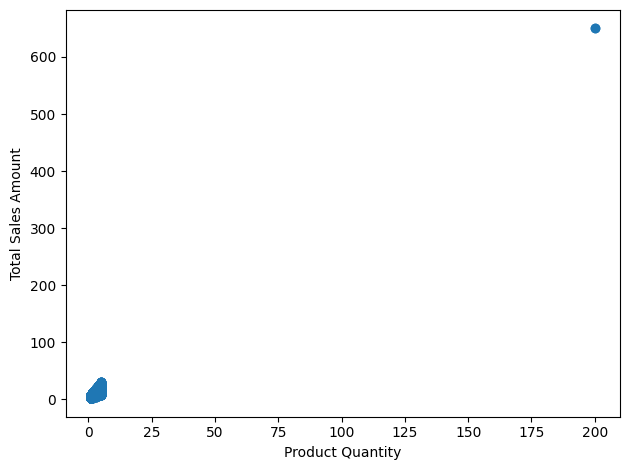

In [14]:
plt.scatter(df['PROD_QTY'],df['TOT_SALES'])
plt.xlabel('Product Quantity')
plt.ylabel('Total Sales Amount')
plt.tight_layout()
plt.show()

In [15]:
# All transactions concentrated below 10 (Quantity) and 50 (Total sales amount), except for 2 transactions

df[df['TOT_SALES'] > 50]
# Both are for Dorito Corn Chp Supreme 380g from the same customer 

df[df['LYLTY_CARD_NBR'] == 226000]
# The customer only has 2 transactions in the whole year (August 2018 and May 2019)
# Probably a customer who bought bulk only twice for resell purposes. Valid bulk purchases, retained in final dataset.

new_df = df[df['TOT_SALES'] < 50]
# A new df removing the 2 high transactions to check the remaining data

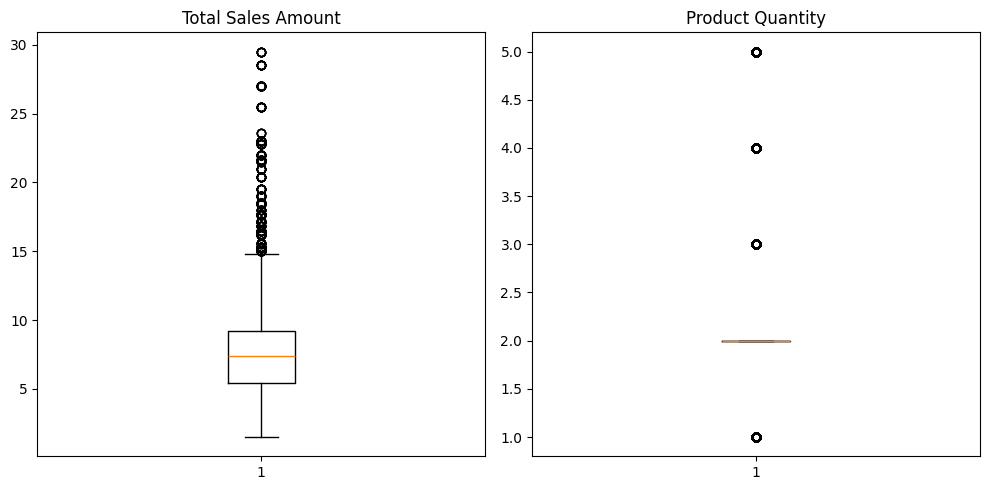

In [16]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.boxplot(new_df['TOT_SALES'])
ax1.set_title('Total Sales Amount')

ax2.boxplot(new_df['PROD_QTY'])
ax2.set_title('Product Quantity')

plt.tight_layout()
plt.show()

In [17]:
new_df['PROD_QTY'].describe()
# Product quantity is concentrated at 2 (Q1, Q3, mean all are 2) with std 0.34. The Outliers according to the box plot are not actual doubtable transactions (Max 5, min 1) 

# Examine Outliers in Total Sales Amount
sale_Q3 = new_df['TOT_SALES'].quantile(0.75)
sale_Q1 = new_df['TOT_SALES'].quantile(0.25)
sale_IQR = sale_Q3 - sale_Q1
outlier = (new_df['TOT_SALES'] > sale_Q3 + 1.5*sale_IQR)
new_df[outlier]
new_df[outlier & (new_df['PROD_QTY'] < 5)]
# None of the transactions are below lower outlier point, safe to check only ones above
# These seem to be legit transactions as well. 

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,BRAND_NAME,MISSING_BRAND_NAME,PACK_SIZE,IS_CHIP
102,2019-05-15,133,133250,137666,30,Doritos Corn Chips Cheese Supreme 170g,4,17.6,Doritos,False,170,True
124,2019-05-17,168,168219,170719,33,Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,4,15.2,Cobs Popd,False,110,True
191,2018-08-17,257,257258,257308,114,Kettle Sensations Siracha Lime 150g,4,18.4,Kettle,False,150,True
193,2018-08-19,262,262126,262025,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,4,18.4,Kettle,False,150,True
5059,2019-05-19,25,25220,21988,42,Doritos Corn Chip Mexican Jalapeno 150g,4,15.6,Doritos,False,150,True
...,...,...,...,...,...,...,...,...,...,...,...,...
238440,2018-08-17,250,250130,252021,7,Smiths Crinkle Original 330g,3,17.1,Smiths,False,330,True
238490,2018-08-19,272,272037,269678,46,Kettle Original 175g,4,21.6,Kettle,False,175,True
258659,2018-08-18,123,123246,127077,104,Infuzions Thai SweetChili PotatoMix 110g,4,15.2,Infuzions,False,110,True
258715,2018-08-16,194,194381,194835,102,Kettle Mozzarella Basil & Pesto 175g,4,21.6,Kettle,False,175,True


Final Checks

In [18]:
print(F"Original Shape: {org_shape}  Final Shape: {df.shape}")
# 1 fully duplicated row removed and 4 new features added

Original Shape: (264836, 8)  Final Shape: (264835, 12)


In [ ]:
df.to_csv('E:\Projects\DataAnalysis\Forage\Quantium\data\processed\clean_QVI_transactions_data.csv', index=False)

Customer File

In [20]:
df_cust = pd.read_csv(r'E:\Projects\DataAnalysis\Forage\Quantium\data\raw\QVI_purchase_behaviour.csv')

In [21]:
df_cust.dtypes
df_cust.isna().sum()
df_cust.shape

(72637, 3)

In [22]:
df_cust['LYLTY_CARD_NBR'].nunique()

assert (df['LYLTY_CARD_NBR'].isin(df_cust['LYLTY_CARD_NBR'])).all()

- 72637 customer - matches the exact count of customers from the transactions file and they all exist across both files
- No nulls

In [23]:
df_cust['PREMIUM_CUSTOMER'].value_counts()
# 3 Customer Segments Premium, Mainstream, Budget

df_cust['LIFESTAGE'].value_counts()
# Customers Divided by 7 life stages 

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

- This dimension file is already clean and is ready to be used, no changes required